Fitting and Calculations


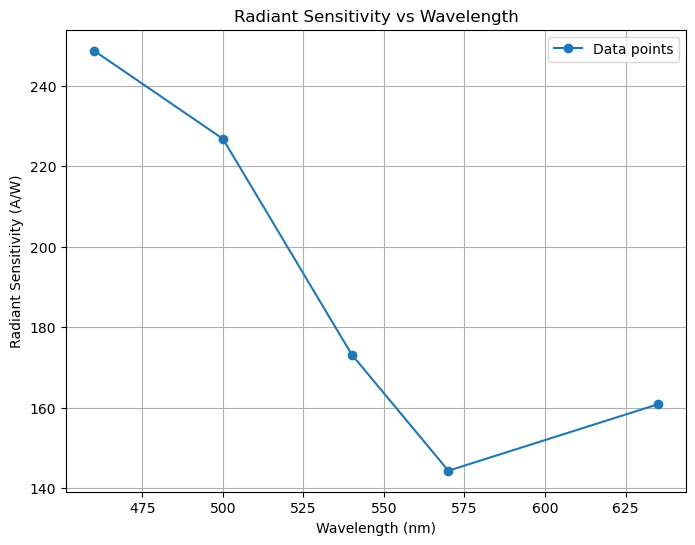

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from prettytable import PrettyTable

x = np.array([500, 635, 570, 460,540])
y = np.array([226.80,160.82,144.33,248.70,173.20])
n = len(x)

# Sort the data by wavelength
sort_indices = np.argsort(x)
x_sorted = x[sort_indices]
y_sorted = y[sort_indices]

# Plot the data points connected by lines
plt.figure(figsize=(8, 6))
plt.plot(x_sorted, y_sorted, 'o-', label='Data points')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Radiant Sensitivity (A/W)')
plt.title('Radiant Sensitivity vs Wavelength')
plt.legend()
plt.grid(True)
plt.show()

+---------------------------------------+
|               Input Data              |
+----+--------+--------+-------+--------+
| i  |   x    |   y    |   x²  |   xy   |
+----+--------+--------+-------+--------+
| 1  | -0.523 | 0.103  | 0.273 | -0.054 |
| 2  | -0.456 | 0.535  | 0.208 | -0.244 |
| 3  | -0.398 |  0.76  | 0.158 | -0.302 |
| 4  | -0.347 | 1.139  |  0.12 | -0.395 |
| 5  | -0.301 | 1.373  | 0.091 | -0.413 |
| 6  | -0.26  | 1.424  | 0.067 | -0.37  |
| 7  | -0.222 | 1.477  | 0.049 | -0.328 |
| 8  | -0.187 | 1.646  | 0.035 | -0.308 |
| 9  | -0.155 | 1.786  | 0.024 | -0.277 |
| 10 | -0.125 | 1.894  | 0.016 | -0.237 |
| 11 | -0.097 | 2.023  | 0.009 | -0.196 |
| Σ  | -3.07  | 14.161 | 1.051 | -3.123 |
+----+--------+--------+-------+--------+ 

+-----------------------------------------+
|     Fit Results & Statistical Errors    |
+------------------+--------+-------------+
|    Parameter     | Value  | Uncertainty |
+------------------+--------+-------------+
|    Slope (a₁)    | 4

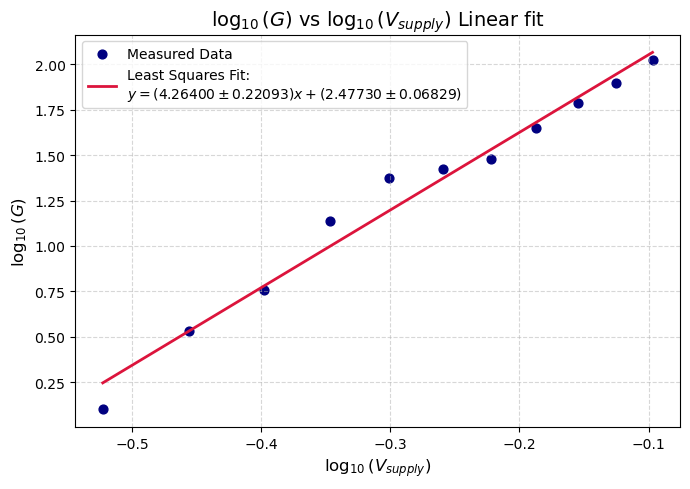

In [2]:
# log10(Gain)
logG = np.array([0.1026, 0.5351, 0.7597, 1.1392, 1.3729,
                 1.4240, 1.4771, 1.6465, 1.7864, 1.8943, 2.0233])

# log10(V_supply)
logV = np.array([-0.5229, -0.4559, -0.3979, -0.3468, -0.3010,
                 -0.2596, -0.2218, -0.1871, -0.1549, -0.1249, -0.0969])

x = logV
y = logG
n = len(x)

table_data = PrettyTable(["i", "x", "y", "x²", "xy"])
for i in range(n):
    table_data.add_row([i+1, round(x[i], 3), round(y[i], 3), round(x[i]**2, 3), round(x[i]*y[i], 3)])
table_data.add_row(["Σ", round(np.sum(x), 3), round(np.sum(y), 3), round(np.sum(x**2), 3), round(np.sum(x*y), 3)])
table_data.title = "Input Data"
print(table_data, "\n")

# --- Least Squares Calculation ---
Sx = np.sum(x)
Sy = np.sum(y)
Sxx = np.sum(x**2)
Sxy = np.sum(x*y)

delta = n*Sxx - Sx**2
a1 = (n*Sxy - Sx*Sy) / delta  # Slope
a0 = (Sxx*Sy - Sx*Sxy) / delta  # Intercept

# --- Error Analysis ---
y_fit = a0 + a1*x
residuals = y - y_fit
sigma_y = np.sqrt(np.sum(residuals**2) / (n-2))
sigma_a1 = sigma_y * np.sqrt(n / delta)
sigma_a0 = sigma_y * np.sqrt(Sxx / delta)

# --- Results Table ---
results = PrettyTable(["Parameter", "Value", "Uncertainty"])
results.title = "Fit Results & Statistical Errors"
results.add_row(["Slope (a₁)", f"{a1:.4f}", f"±{sigma_a1:.4f}"])
results.add_row(["Intercept (a₀)", f"{a0:.4f}", f"±{sigma_a0:.4f}"])
results.add_row(["σ_y (Std. Error)", f"{sigma_y:.4f}", ""])
results.add_row(["Δ (delta)", f"{delta:.4f}", ""])
print(results, "\n")

# --- Fitted Values Table ---
fit_table = PrettyTable(["x", "y (measured)", "y (fit)"])
fit_table.title = "Measured vs Fitted Values"
for xi, yi, yfi in zip(x, y, y_fit):
    fit_table.add_row([round(xi, 3), round(yi, 3), round(yfi, 3)])
print(fit_table, "\n")

# --- Plotting ---
plt.figure(figsize=(7,5))
plt.scatter(x, y, color='navy', label='Measured Data', s=40)
plt.plot(x, y_fit, color='crimson', linewidth=2,
         label=f'Least Squares Fit:\n$y = ({a1:.5f} \pm {sigma_a1:.5f})x + ({a0:.5f} \pm {sigma_a0:.5f})$')
plt.xlabel(r"$\log_{10}(V_{supply})$", fontsize=12)
plt.ylabel(r"$\log_{10}(G)$", fontsize=12)
plt.title(r"$\log_{10}(G)$ vs $\log_{10}(V_{supply})$ Linear fit", fontsize=14)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Wavelength (nm) | R (A/W) | ± Error (A/W) | Rel. Error (%)
----------------------------------------------------------------------
       460 |   248.70 |     248.71 |       100.00
       500 |   226.80 |     226.81 |       100.00
       540 |   173.20 |     173.20 |       100.00
       570 |   144.33 |     144.33 |       100.00
       635 |   160.82 |     160.83 |       100.00


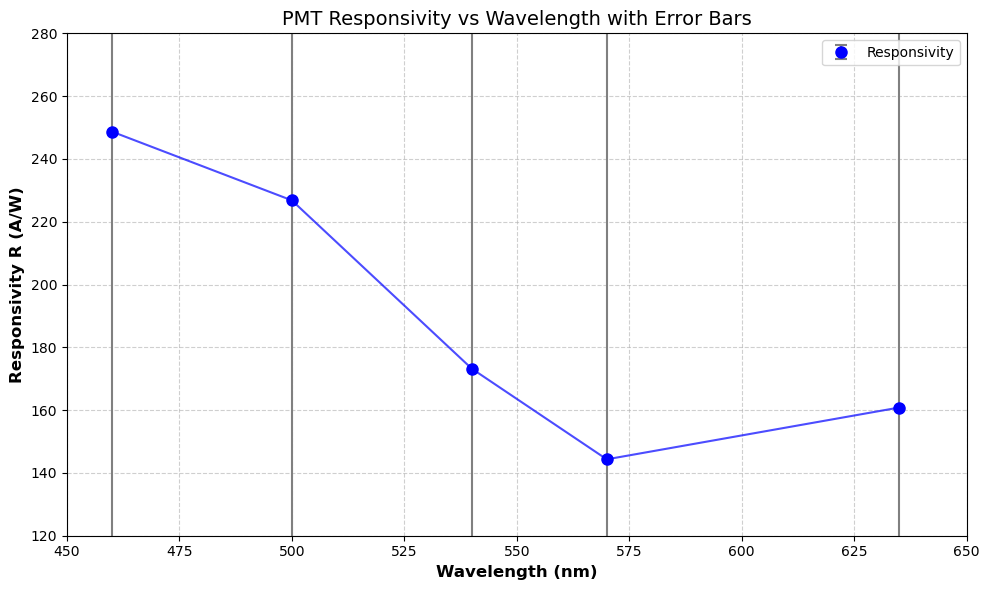

In [3]:
wavelengths = np.array([460, 500, 540, 570, 635])   

V_PD   = np.array([0.193, 0.194, 0.194, 0.194, 0.194])   # Photodiode voltage (V)
I_PD   = np.array([0.1,   0.1,   0.1,   0.1,   0.1  ])   # Photodiode current (µA)
V_PMT  = np.array([4.80,  4.40,  3.36,  2.80,  3.12 ])   # PMT output voltage (V)

# Sort by wavelength
sort_idx = np.argsort(wavelengths)
wavelengths = wavelengths[sort_idx]
V_PD   = V_PD[sort_idx]
I_PD   = I_PD[sort_idx]
V_PMT  = V_PMT[sort_idx]

R = V_PMT / (V_PD * I_PD)

dV = 0.001
dV1 = 0.01
dI = 0.1   # µA

# Propagation of errors (independent, uncorrelated)
rel_err_VPMT = dV1 / V_PMT
rel_err_VPD  = dV / V_PD
rel_err_IPD  = dI / I_PD

rel_err_R = np.sqrt(rel_err_VPMT**2 + rel_err_VPD**2 + rel_err_IPD**2)
abs_err_R = R * rel_err_R

# Print results
print("Wavelength (nm) | R (A/W) | ± Error (A/W) | Rel. Error (%)")
print("-" * 70)
for wl, r, err in zip(wavelengths, R, abs_err_R):
    print(f"{wl:10d} | {r:8.2f} | {err:10.2f} | {err/r*100:12.2f}")

plt.figure(figsize=(10, 6))
plt.errorbar(wavelengths, R, yerr=abs_err_R, fmt='o',
             color='blue', ecolor='gray', capsize=4, capthick=1.5,
             markersize=8, label='Responsivity', elinewidth=1.5)
plt.plot(wavelengths, R, color='blue', linestyle='-', alpha=0.7)
plt.xlabel('Wavelength (nm)', fontsize=12, fontweight='bold')
plt.ylabel('Responsivity R (A/W)', fontsize=12, fontweight='bold')
plt.title('PMT Responsivity vs Wavelength with Error Bars', fontsize=14)

plt.grid(True, linestyle='--', alpha=0.6)
plt.xlim(450, 650)
plt.ylim(120, 280)   # Adjust based on your R range
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

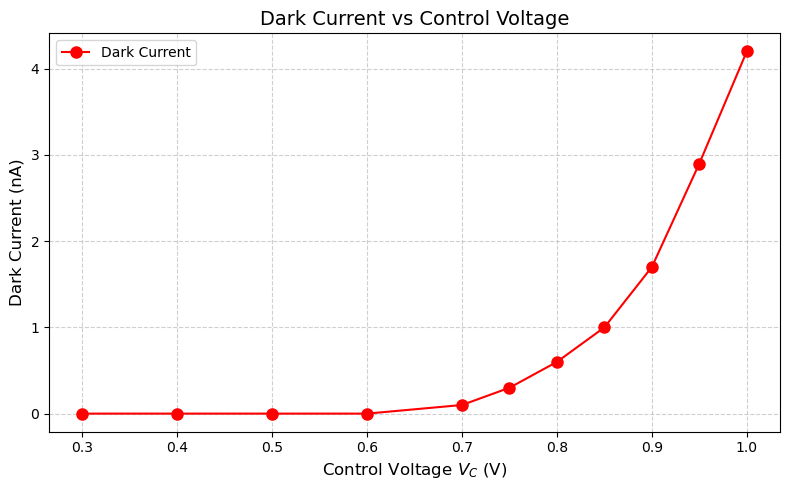

In [4]:
V_C = np.array([0.30, 0.40, 0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 1.00])
V_PMT_original = np.array([0.000, 0.000, 0.000, 0.000, 0.001, 0.003, 0.006, 0.010, 0.017, 0.029, 0.042])

I_dark = V_PMT_original * 100   # nA

plt.figure(figsize=(8, 5))
plt.plot(V_C, I_dark, 'o', color='red', linestyle='-', markersize=8, label='Dark Current')
plt.xlabel('Control Voltage $V_C$ (V)', fontsize=12)
plt.ylabel('Dark Current (nA)', fontsize=12)
plt.title('Dark Current vs Control Voltage', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()